# Лабораторна робота №2

## NumPy, pandas і Matplotlib для підготовки, аналізу та візуалізації даних

**Студент:** Люлько Станіслав
**Група:** МІТ-31
**Номер варіанта:** 17   

### Тема
NumPy, pandas і Matplotlib для підготовки, аналізу та візуалізації даних.

### Мета
Ознайомитися з основами роботи з бібліотеками NumPy, pandas та Matplotlib для аналізу даних, проведення базових операцій з даними та візуалізації результатів.

### Предметна область
Заряд акумулятора.

- Вісь X: Час, хв
- Вісь Y: Заряд, %
- `a = -0.65`
- `b = 98.0`
- `σ = 1.5`
- `seed = 17`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Висновок

Було імпортовано бібліотеки NumPy, pandas та Matplotlib, які використовуються відповідно для числових обчислень, роботи з табличними даними та побудови графіків.

In [2]:
# Параметри варіанта 17 (варіант 7)
seed = 17

a = -0.65
b = 98.0
sigma = 1.5

# Генератор випадкових чисел
rng = np.random.default_rng(seed)

# 100 рівномірно розподілених значень часу від 0 до 20 хв
x = np.linspace(0, 20, 100)

# Теоретичні значення заряду акумулятора
y_hat = a * x + b

# Випадковий шум
noise = rng.normal(
    loc=0,
    scale=sigma,
    size=x.size
)

# Спостережувані значення
y_observed = y_hat + noise

print("Кількість значень:", x.size)
print("Перші 5 значень X:", x[:5])
print("Перші 5 теоретичних значень:", y_hat[:5])
print("Перші 5 значень шуму:", noise[:5])
print("Перші 5 спостережуваних значень:", y_observed[:5])

Кількість значень: 100
Перші 5 значень X: [0.         0.2020202  0.4040404  0.60606061 0.80808081]
Перші 5 теоретичних значень: [98.         97.86868687 97.73737374 97.60606061 97.47474747]
Перші 5 значень шуму: [ 1.65189368  0.50764691 -0.80995727 -1.89036279 -2.8419319 ]
Перші 5 спостережуваних значень: [99.65189368 98.37633378 96.92741646 95.71569782 94.63281557]


### Висновок

Було сформовано 100 значень часу в діапазоні від 0 до 20 хвилин. Теоретичний заряд акумулятора обчислено за формулою `y_hat = a · x + b`.

Для моделювання реальних вимірювань до теоретичних значень додано випадковий нормально розподілений шум із параметром `σ = 1.5`.

In [3]:
data_matrix = np.column_stack(
    (x, y_hat, noise, y_observed)
)

print("Матриця даних:")
print(data_matrix[:5])

print("\nФорма масиву shape:", data_matrix.shape)
print("Кількість вимірів ndim:", data_matrix.ndim)
print("Кількість елементів size:", data_matrix.size)
print("Тип даних dtype:", data_matrix.dtype)

Матриця даних:
[[ 0.         98.          1.65189368 99.65189368]
 [ 0.2020202  97.86868687  0.50764691 98.37633378]
 [ 0.4040404  97.73737374 -0.80995727 96.92741646]
 [ 0.60606061 97.60606061 -1.89036279 95.71569782]
 [ 0.80808081 97.47474747 -2.8419319  94.63281557]]

Форма масиву shape: (100, 4)
Кількість вимірів ndim: 2
Кількість елементів size: 400
Тип даних dtype: float64


### Висновок

Отримано двовимірний масив NumPy розміром 100 × 4.

Перший стовпець містить час, другий — теоретичний заряд акумулятора, третій — шум, а четвертий — спостережуваний заряд.

Властивість `shape` показує кількість рядків і стовпців, `ndim` — кількість вимірів масиву, `size` — загальну кількість елементів, а `dtype` — тип даних елементів.

In [4]:
# Читання окремого елемента через індекс
print("Елемент [0, 0]:", data_matrix[0, 0])

# Зріз перших 5 рядків
print("\nПерші 5 рядків:")
print(data_matrix[:5])

# Зріз перших двох стовпців
print("\nПерші 5 рядків та 2 перші стовпці:")
print(data_matrix[:5, :2])

# Булева фільтрація:
# вибираємо спостереження, де заряд більше 90 %
filtered_matrix = data_matrix[data_matrix[:, 3] > 90]

print(
    "\nКількість рядків із зарядом > 90 %:",
    filtered_matrix.shape[0]
)

print(filtered_matrix[:5])

# Створюємо копію фрагмента
fragment_copy = data_matrix[:5, :].copy()

print("\nФрагмент до зміни:")
print(fragment_copy)

# Змінюємо значення тільки в копії
fragment_copy[0, 3] = -999

print("\nЗмінений фрагмент-копія:")
print(fragment_copy)

print("\nОригінальний масив після зміни копії:")
print(data_matrix[:5])

# Видалення одного елемента з копії
deleted_array = np.delete(
    data_matrix.copy(),
    0
)

print(
    "\nКількість елементів після видалення одного елемента:",
    deleted_array.size
)

Елемент [0, 0]: 0.0

Перші 5 рядків:
[[ 0.         98.          1.65189368 99.65189368]
 [ 0.2020202  97.86868687  0.50764691 98.37633378]
 [ 0.4040404  97.73737374 -0.80995727 96.92741646]
 [ 0.60606061 97.60606061 -1.89036279 95.71569782]
 [ 0.80808081 97.47474747 -2.8419319  94.63281557]]

Перші 5 рядків та 2 перші стовпці:
[[ 0.         98.        ]
 [ 0.2020202  97.86868687]
 [ 0.4040404  97.73737374]
 [ 0.60606061 97.60606061]
 [ 0.80808081 97.47474747]]

Кількість рядків із зарядом > 90 %: 61
[[ 0.         98.          1.65189368 99.65189368]
 [ 0.2020202  97.86868687  0.50764691 98.37633378]
 [ 0.4040404  97.73737374 -0.80995727 96.92741646]
 [ 0.60606061 97.60606061 -1.89036279 95.71569782]
 [ 0.80808081 97.47474747 -2.8419319  94.63281557]]

Фрагмент до зміни:
[[ 0.         98.          1.65189368 99.65189368]
 [ 0.2020202  97.86868687  0.50764691 98.37633378]
 [ 0.4040404  97.73737374 -0.80995727 96.92741646]
 [ 0.60606061 97.60606061 -1.89036279 95.71569782]
 [ 0.80808081 9

### Висновок

Було продемонстровано доступ до елементів NumPy-масиву через індекси та зрізи, булеву фільтрацію, а також видалення елемента.

Для зміни частини масиву було використано `copy()`. Це запобігає випадковій зміні вихідного масиву при роботі з фрагментом.

In [5]:
y_min = np.min(y_observed)
y_max = np.max(y_observed)
y_mean = np.mean(y_observed)
y_std = np.std(y_observed)

print("Мінімальний заряд:", y_min, "%")
print("Максимальний заряд:", y_max, "%")
print("Середній заряд:", y_mean, "%")
print("Стандартне відхилення:", y_std, "%")

# Агрегація по axis=0
stats_axis0 = np.array([
    np.min(data_matrix, axis=0),
    np.max(data_matrix, axis=0),
    np.mean(data_matrix, axis=0),
    np.std(data_matrix, axis=0)
])

print("\nАгрегація по axis=0:")
print(stats_axis0)

Мінімальний заряд: 83.42264959686644 %
Максимальний заряд: 99.65189368025877 %
Середній заряд: 91.29750591931953 %
Стандартне відхилення: 3.954357633585316 %

Агрегація по axis=0:
[[ 0.         85.         -3.65312612 83.4226496 ]
 [20.         98.          4.35537268 99.65189368]
 [10.         91.5        -0.20249408 91.29750592]
 [ 5.8315293   3.79049405  1.61481153  3.95435763]]


### Висновок

Для спостережуваного заряду акумулятора було обчислено мінімальне, максимальне та середнє значення, а також стандартне відхилення.

Агрегація з `axis=0` виконує обчислення окремо для кожного стовпця матриці.

In [6]:
df = pd.DataFrame({
    "x": x,
    "y_true": y_hat,
    "noise": noise,
    "y_observed": y_observed
})

# Поділ X на три рівні інтервали
df["group"] = pd.cut(
    df["x"],
    bins=3,
    labels=["low", "medium", "high"],
    include_lowest=True
)

print(df.head())

          x     y_true     noise  y_observed group
0  0.000000  98.000000  1.651894   99.651894   low
1  0.202020  97.868687  0.507647   98.376334   low
2  0.404040  97.737374 -0.809957   96.927416   low
3  0.606061  97.606061 -1.890363   95.715698   low
4  0.808081  97.474747 -2.841932   94.632816   low


### Висновок

Було створено DataFrame зі стовпцями `x`, `y_true`, `noise`, `y_observed` та `group`.

Дані за значенням часу було поділено на три рівні інтервали: `low`, `medium` та `high`.

In [7]:
print("Перші 5 рядків:")
display(df.head())

print("\nФорма DataFrame:")
print(df.shape)

print("\nТипи даних:")
print(df.dtypes)

print("\nІнформація про DataFrame:")
df.info()

print("\nОписова статистика:")
display(df.describe())

Перші 5 рядків:


,x,y_true,noise,y_observed,group
0,0.000000,98.000000,1.651894,99.651894,low
1,0.202020,97.868687,0.507647,98.376334,low
2,0.404040,97.737374,-0.809957,96.927416,low
3,0.606061,97.606061,-1.890363,95.715698,low
4,0.808081,97.474747,-2.841932,94.632816,low



Форма DataFrame:
(100, 5)

Типи даних:
x              float64
y_true         float64
noise          float64
y_observed     float64
group         category
dtype: object

Інформація про DataFrame:
<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   x           100 non-null    float64 
 1   y_true      100 non-null    float64 
 2   noise       100 non-null    float64 
 3   y_observed  100 non-null    float64 
 4   group       100 non-null    category
dtypes: category(1), float64(4)
memory usage: 3.5 KB

Описова статистика:


,x,y_true,noise,y_observed
count,100.000000,100.00000,100.000000,100.000000
mean,10.000000,91.50000,-0.202494,91.297506
std,5.860907,3.80959,1.622947,3.974279
min,0.000000,85.00000,-3.653126,83.422650
25%,5.000000,88.25000,-1.310923,87.944153
50%,10.000000,91.50000,-0.169381,90.963770
75%,15.000000,94.75000,0.843197,94.146334
max,20.000000,98.00000,4.355373,99.651894


### Висновок

Первинний аналіз показав структуру таблиці, кількість рядків і стовпців та типи даних кожного стовпця.

Метод `describe()` дозволяє отримати основні статистичні характеристики числових даних.

In [8]:
# Створюємо копію DataFrame
df_dirty = df.copy()

# Додаємо три пропуски до y_observed
df_dirty.loc[10, "y_observed"] = np.nan
df_dirty.loc[30, "y_observed"] = np.nan
df_dirty.loc[70, "y_observed"] = np.nan

# Додаємо один дубльований рядок
df_dirty = pd.concat(
    [df_dirty, df_dirty.iloc[[20]]],
    ignore_index=True
)

print(
    "Форма після додавання пропусків і дубліката:",
    df_dirty.shape
)

print("\nКількість пропусків:")
print(df_dirty.isna().sum())

print("\nКількість дублікатів:")
print(df_dirty.duplicated().sum())

Форма після додавання пропусків і дубліката: (101, 5)

Кількість пропусків:
x             0
y_true        0
noise         0
y_observed    3
group         0
dtype: int64

Кількість дублікатів:
1


### Висновок

Для демонстрації очищення даних було створено копію початкового DataFrame.

До неї додано три пропущені значення у стовпці `y_observed` та один дубльований рядок.

Методи `isna()` та `duplicated()` дозволили визначити кількість пропусків і дублікатів.

In [9]:
# Форма до очищення
print("Форма до очищення:", df_dirty.shape)

# Видаляємо дублікати
df_clean = df_dirty.drop_duplicates().copy()

print(
    "Форма після видалення дубліката:",
    df_clean.shape
)

# Обчислюємо медіану
median_value = df_clean["y_observed"].median()

# Заповнюємо пропуски медіаною
df_clean.loc[:, "y_observed"] = (
    df_clean["y_observed"].fillna(median_value)
)

print("\nМедіана y_observed:", median_value)

print("\nПропуски після очищення:")
print(df_clean.isna().sum())

print("\nДублікати після очищення:")
print(df_clean.duplicated().sum())

print("\nФорма після очищення:")
print(df_clean.shape)

Форма до очищення: (101, 5)
Форма після видалення дубліката: (100, 5)

Медіана y_observed: 90.86677445624954

Пропуски після очищення:
x             0
y_true        0
noise         0
y_observed    0
group         0
dtype: int64

Дублікати після очищення:
0

Форма після очищення:
(100, 5)


### Висновок

Спочатку було видалено дубльований рядок, після чого кількість рядків зменшилася на один.

Пропущені значення у `y_observed` було заповнено медіаною. Медіана є стійкішою до можливих викидів, ніж середнє значення.

Після очищення у таблиці відсутні пропуски та дублікати.

In [10]:
# loc — доступ за назвами стовпців та індексами
print("Приклад loc:")
display(
    df_clean.loc[
        0:4,
        ["x", "y_observed", "group"]
    ]
)

# iloc — доступ за числовими позиціями
print("Приклад iloc:")
display(
    df_clean.iloc[0:5, 0:3]
)

# Булева фільтрація
print("Значення заряду більше 95 %:")
display(
    df_clean.loc[
        df_clean["y_observed"] > 95,
        ["x", "y_observed", "group"]
    ].head(10)
)

# Сортування
sorted_df = df_clean.sort_values(
    by="y_observed",
    ascending=False
)

print("П'ять найбільших значень заряду:")
display(
    sorted_df[
        ["x", "y_observed", "group"]
    ].head()
)

Приклад loc:


,x,y_observed,group
0,0.000000,99.651894,low
1,0.202020,98.376334,low
2,0.404040,96.927416,low
3,0.606061,95.715698,low
4,0.808081,94.632816,low


Приклад iloc:


,x,y_true,noise
0,0.000000,98.000000,1.651894
1,0.202020,97.868687,0.507647
2,0.404040,97.737374,-0.809957
3,0.606061,97.606061,-1.890363
4,0.808081,97.474747,-2.841932


Значення заряду більше 95 %:


,x,y_observed,group
0,0.000000,99.651894,low
1,0.202020,98.376334,low
2,0.404040,96.927416,low
3,0.606061,95.715698,low
5,1.010101,97.371392,low
6,1.212121,95.996271,low
7,1.414141,95.772574,low
8,1.616162,96.616541,low
9,1.818182,96.740413,low
11,2.222222,97.943275,low


П'ять найбільших значень заряду:


,x,y_observed,group
0,0.000000,99.651894,low
13,2.626263,99.082365,low
1,0.202020,98.376334,low
11,2.222222,97.943275,low
16,3.232323,97.913485,low


### Висновок

Було продемонстровано два способи доступу до даних у pandas: `loc` працює за мітками, а `iloc` — за числовими позиціями.

Також виконано булеву фільтрацію для пошуку вимірювань із зарядом понад 95 % та сортування даних за значенням спостережуваного заряду.

In [11]:
summary = (
    df_clean
    .groupby("group", observed=True)["y_observed"]
    .agg(
        mean="mean",
        std="std",
        count="size"
    )
    .reset_index()
)

print("Агрегована таблиця:")
display(summary)

Агрегована таблиця:


,group,mean,std,count
0,low,95.445880,2.397623,34
1,medium,90.992409,1.692070,33
2,high,87.330034,2.189000,33


### Висновок

Дані було згруповано за трьома часовими інтервалами: `low`, `medium` та `high`.

Для кожної групи обчислено середнє значення заряду, стандартне відхилення та кількість рядків.

Метод `size()` враховує всі рядки групи, тоді як `count()` під час підрахунку конкретного стовпця не враховує пропущені значення.

In [12]:
# Перетворення Series у NumPy-масиви
y_observed_array = df_clean["y_observed"].to_numpy()
y_true_array = df_clean["y_true"].to_numpy()

# Помилка
errors = y_observed_array - y_true_array

# MAE
mae = np.mean(np.abs(errors))

# MSE
mse = np.mean(errors ** 2)

print(f"MAE = {mae:.4f} %")
print(f"MSE = {mse:.4f} (%²)")

print("\nПеревірка:")
print("MAE >= 0:", mae >= 0)
print("MSE >= 0:", mse >= 0)

MAE = 1.3264 %
MSE = 2.9504 (%²)

Перевірка:
MAE >= 0: True
MSE >= 0: True


### Висновок

MAE показує середню абсолютну похибку між спостережуваним і теоретичним зарядом акумулятора та вимірюється у відсоткових пунктах.

MSE є середнім квадратом похибки та вимірюється у квадраті одиниць цільової змінної.

Через піднесення похибок до квадрата MSE сильніше реагує на великі відхилення. Обидві метрики є невід'ємними.

In [13]:
df_clean.loc[:, "absolute_error"] = np.abs(
    df_clean["y_observed"] - df_clean["y_true"]
)

df_clean.loc[:, "squared_error"] = (
    df_clean["y_observed"] - df_clean["y_true"]
) ** 2

display(df_clean.head())

,x,y_true,noise,y_observed,group,absolute_error,squared_error
0,0.000000,98.000000,1.651894,99.651894,low,1.651894,2.728753
1,0.202020,97.868687,0.507647,98.376334,low,0.507647,0.257705
2,0.404040,97.737374,-0.809957,96.927416,low,0.809957,0.656031
3,0.606061,97.606061,-1.890363,95.715698,low,1.890363,3.573471
4,0.808081,97.474747,-2.841932,94.632816,low,2.841932,8.076577


### Висновок

До очищеної таблиці додано два нові стовпці:

- `absolute_error` — абсолютна похибка;
- `squared_error` — квадрат похибки.

Ці стовпці дозволяють зберігати похибку для кожного окремого вимірювання.

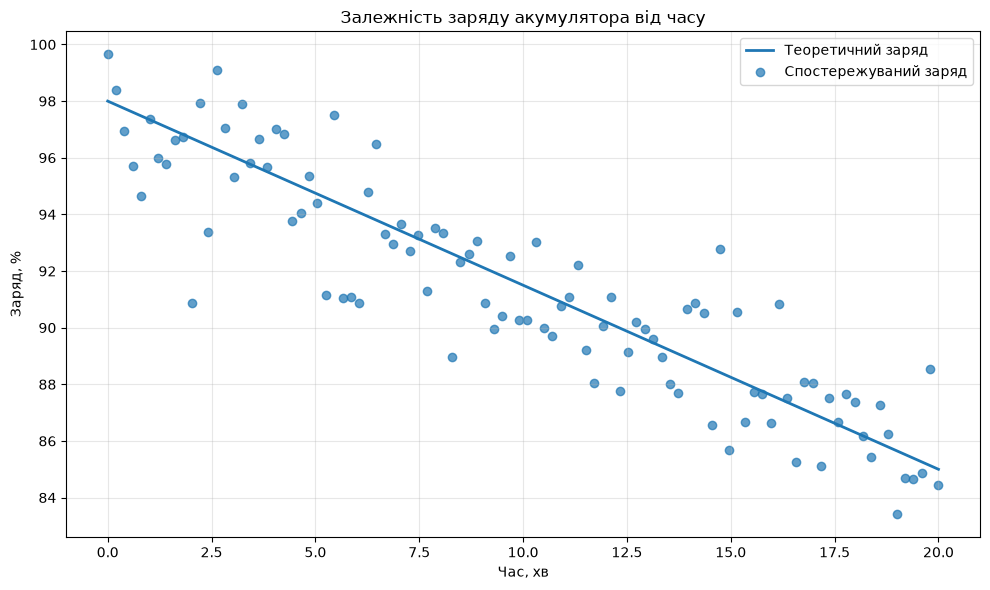

In [14]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    df_clean["x"],
    df_clean["y_true"],
    label="Теоретичний заряд",
    linewidth=2
)

ax.scatter(
    df_clean["x"],
    df_clean["y_observed"],
    label="Спостережуваний заряд",
    alpha=0.7
)

ax.set_title("Залежність заряду акумулятора від часу")
ax.set_xlabel("Час, хв")
ax.set_ylabel("Заряд, %")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()

fig.savefig(
    "Lab2_battery_charge.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Висновок

На графіку показано теоретичну залежність заряду акумулятора від часу та фактичні спостереження з доданим випадковим шумом.

Оскільки коефіцієнт `a = -0.65`, теоретичний заряд поступово зменшується зі збільшенням часу. Спостережувані значення розташовані навколо теоретичної лінії через наявність випадкового шуму.

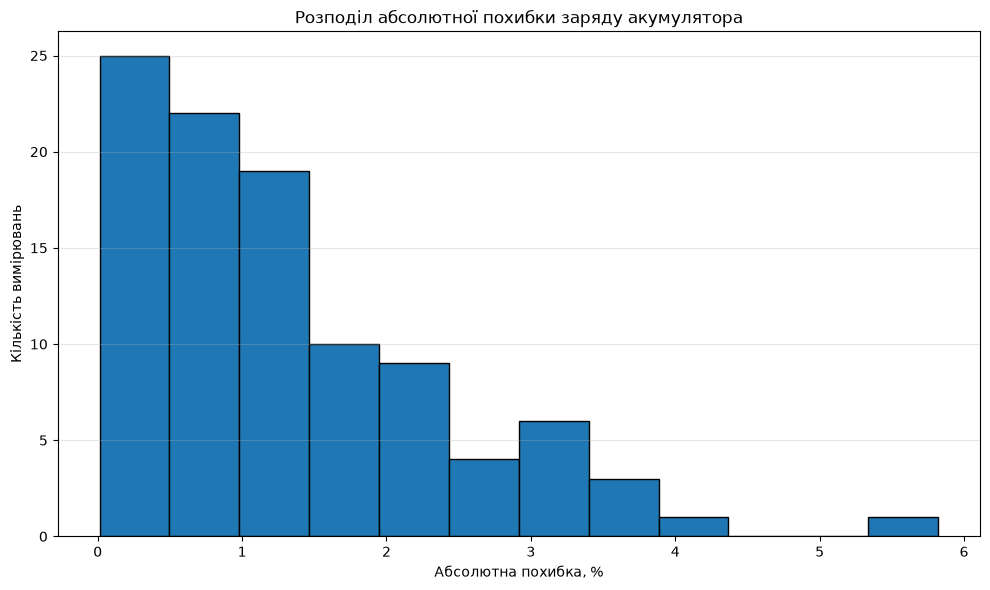

In [15]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(
    df_clean["absolute_error"],
    bins=12,
    edgecolor="black"
)

ax.set_title("Розподіл абсолютної похибки заряду акумулятора")
ax.set_xlabel("Абсолютна похибка, %")
ax.set_ylabel("Кількість вимірювань")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()

fig.savefig(
    "Lab2_absolute_error_histogram.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Висновок

Гістограма показує розподіл абсолютної похибки вимірювань заряду акумулятора.

Більшість значень похибки зосереджена в області невеликих відхилень, що відповідає використаній моделі випадкового шуму з `σ = 1.5`.

In [16]:
# Очищена таблиця у CSV
df_clean.to_csv(
    "Lab2_results.csv",
    index=False
)

# Очищена таблиця у Parquet
df_clean.to_parquet(
    "Lab2_results.parquet",
    index=False
)

# Агрегована таблиця
summary.to_csv(
    "Lab2_summary.csv",
    index=False
)

print("Файли успішно збережено:")
print("- Lab2_results.csv")
print("- Lab2_results.parquet")
print("- Lab2_summary.csv")
print("- Lab2_battery_charge.png")
print("- Lab2_absolute_error_histogram.png")

Файли успішно збережено:
- Lab2_results.csv
- Lab2_results.parquet
- Lab2_summary.csv
- Lab2_battery_charge.png
- Lab2_absolute_error_histogram.png


### Висновок

Очищені дані збережено у форматах CSV та Parquet, а агреговані результати — у CSV.

Побудовані графіки збережено у форматі PNG із роздільною здатністю 300 dpi.

In [17]:
df_loaded = pd.read_csv(
    "Lab2_results.csv"
)

print("Форма початкового очищеного DataFrame:")
print(df_clean.shape)

print("\nФорма повторно завантаженого CSV:")
print(df_loaded.shape)

print(
    "\nФорми однакові:",
    df_clean.shape == df_loaded.shape
)

Форма початкового очищеного DataFrame:
(100, 7)

Форма повторно завантаженого CSV:
(100, 7)

Форми однакові: True


### Висновок

Збережений CSV-файл було повторно прочитано за допомогою `pd.read_csv()`.

Форма завантаженої таблиці збігається з формою очищеного DataFrame, тому збереження та повторне читання даних виконано коректно.

In [18]:
print("===== ФІНАЛЬНА ПЕРЕВІРКА =====")

print("\nФорма очищених даних:")
print(df_clean.shape)

print("\nПропуски:")
print(df_clean.isna().sum())

print("\nДублікати:")
print(df_clean.duplicated().sum())

print("\nMAE:")
print(round(mae, 4))

print("\nMSE:")
print(round(mse, 4))

print("\nАгрегована таблиця:")
display(summary)

===== ФІНАЛЬНА ПЕРЕВІРКА =====

Форма очищених даних:
(100, 7)

Пропуски:
x                 0
y_true            0
noise             0
y_observed        0
group             0
absolute_error    0
squared_error     0
dtype: int64

Дублікати:
0

MAE:
1.3264

MSE:
2.9504

Агрегована таблиця:


,group,mean,std,count
0,low,95.445880,2.397623,34
1,medium,90.992409,1.692070,33
2,high,87.330034,2.189000,33


### Висновок

Після очищення DataFrame не містить пропущених значень і дубльованих рядків.

Було виконано статистичний аналіз, групування даних, розрахунок MAE та MSE, побудовано два графіки та збережено результати у необхідних форматах.